![a3uAqnb.png](https://i.imgur.com/a3uAqnb.png)

# Parameter-Efficient Fine-Tuning (PEFT)



Parameter-Efficient Fine-Tuning (PEFT) is an approach for adapting a pretrained model to a downstream task while training only a small number of parameters, instead of updating all parameters in the model.

In traditional Full Fine-Tuning, all or most pretrained parameters are updated during training.

In PEFT, most of the pretrained model remains frozen, while only a small set of task-specific parameters is optimized. [*(Ref)*](https://huggingface.co/docs/peft/index)

Conceptually:

$$
\theta_{\text{base}} = \text{frozen pretrained parameters}
$$

$$
\phi = \text{small set of trainable parameters}
$$

where:

$$
|\phi| \ll |\theta_{\text{base}}|
$$



Modern pretrained language models can contain hundreds of millions or billions of parameters.
Updating every parameter for every new task can require substantial:

- GPU memory
- computation
- training time
- model storage

<p align="center">
  <img src="https://towardsdatascience.com/wp-content/uploads/2023/08/0bsEuw4SQkYzs6oAJ.png" width="750">
</p>

<p align="center">
  <em>Source: Towards Data Science</em>
</p>

## 3- Quantized Low-Rank Adaptation (QLoRA)

**QLoRA** is a parameter-efficient fine-tuning method introduced by **Dettmers et al. (2023)**. It combines **4-bit quantization** of the pretrained model with **LoRA adapters**, allowing large language models to be fine-tuned using substantially less GPU memory. [*(Ref)*](https://arxiv.org/abs/2305.14314)


In standard LoRA:

$$
W' = W + BA
$$

where:

- $W$ is the frozen pretrained weight matrix.
- $A$ and $B$ are small trainable LoRA matrices.

QLoRA keeps the same LoRA idea, but stores the frozen pretrained weights $W$ in **4-bit precision**:

$$
W_{4bit}
$$

while the LoRA parameters remain trainable.


### QLoRA Numerical Example

Suppose the pretrained model has:

$1,000,000,000$ parameters

If stored in 16-bit precision:

$1,000,000,000 \times 2 \text{ bytes} = 2 \text{ GB}$

With QLoRA, the frozen base model is stored in 4-bit precision:

$1,000,000,000 \times 0.5 \text{ byte} = 0.5 \text{ GB}$

So the base-model weight memory is reduced approximately from:

$2 \text{ GB} \rightarrow 0.5 \text{ GB}$

while the small LoRA adapters remain trainable.

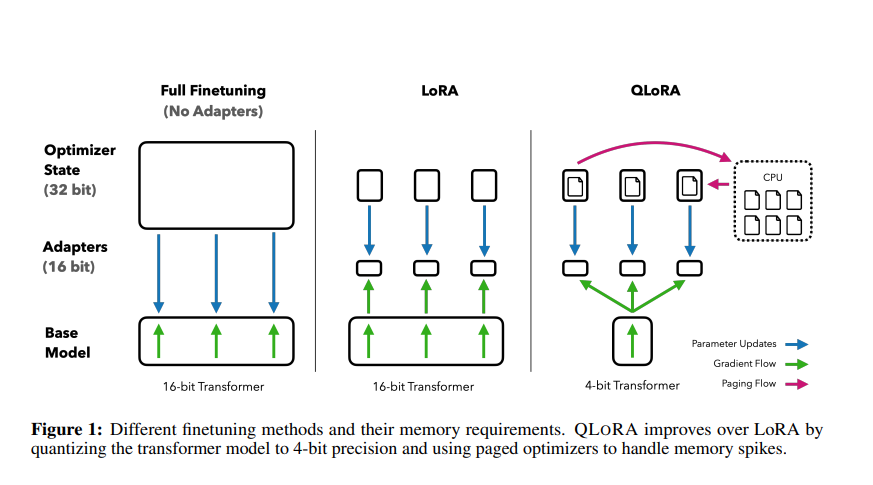

**Figure:** Comparison of Full Fine-Tuning, LoRA, and QLoRA. QLoRA reduces memory usage by quantizing the frozen base model to 4-bit precision while training LoRA adapters, and uses paged optimizers to manage memory spikes. [*(Ref)*](https://arxiv.org/abs/2305.14314)

In [ ]:
from datasets import load_dataset

TASK_NAME = "mnli"
TRAIN_SIZE = 20_000
VAL_SIZE = 2_000

dataset = load_dataset("nyu-mll/glue", TASK_NAME)

train_data = dataset["train"].shuffle(seed=42).select(range(TRAIN_SIZE))
val_data = dataset["validation_matched"].shuffle(seed=42).select(range(VAL_SIZE))

label_names = dataset["train"].features["label"].names
id2label = {i: label for i, label in enumerate(label_names)}
label2id = {label: i for i, label in enumerate(label_names)}

print("Task:", TASK_NAME)
print("Labels:", label_names)
print("Train examples:", len(train_data))
print("Validation examples:", len(val_data))

#### A- QLORA

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

QWEN_MODEL_ID = "Qwen/Qwen2.5-0.5B"

qwen_tokenizer = AutoTokenizer.from_pretrained(QWEN_MODEL_ID)
qwen_tokenizer.pad_token = qwen_tokenizer.eos_token

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,

)

qlora_model = AutoModelForCausalLM.from_pretrained(QWEN_MODEL_ID, quantization_config=quant_config, device_map="auto")
qlora_model = prepare_model_for_kbit_training(qlora_model)

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

qlora_model = get_peft_model(qlora_model, lora_config)

qlora_model.print_trainable_parameters()

In [ ]:
def format_mnli(example):
    return {
        "prompt": f"Premise: {example['premise']}\nHypothesis: {example['hypothesis']}\nRelationship:",
        "completion": f" {label_names[example['label']]}"
    }

qlora_train = train_data.map(format_mnli, remove_columns=train_data.column_names)
qlora_val = val_data.map(format_mnli, remove_columns=val_data.column_names)

print(qlora_train[0])

#### B-Training

In [ ]:
import torch
from trl import SFTConfig, SFTTrainer

# Show trainable parameters
total_params = sum(p.numel() for p in qlora_model.parameters())
trainable_params = sum(
    p.numel() for p in qlora_model.parameters()
    if p.requires_grad
)

print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print(f"Trainable percentage : {100 * trainable_params / total_params:.4f}%")

# QLoRA training configuration
training_args = SFTConfig(
    output_dir="./qwen_qlora_mnli",
    num_train_epochs=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    learning_rate=1e-4,
    max_length=128,
    completion_only_loss=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=100,
    report_to="none",
    bf16=torch.cuda.is_bf16_supported(),
)

# Trainer
qlora_trainer = SFTTrainer(
    model=qlora_model,
    args=training_args,
    train_dataset=qlora_train,
    eval_dataset=qlora_val,
    processing_class=qwen_tokenizer,
)

# Train
print("\nTraining Qwen with QLoRA...")

qlora_train_result = qlora_trainer.train()

print("\nQLoRA training finished.")

# Final validation
eval_results = qlora_trainer.evaluate()

print("\nQLoRA Final Results")
print("-" * 30)
print(f"Training Loss   : {qlora_train_result.training_loss:.4f}")
print(f"Validation Loss : {eval_results['eval_loss']:.4f}")

Prepared by:Lama

### Why is the QLoRA trainable percentage larger?

The trainable percentage is calculated as:

$
\text{Trainable \%} =
\frac{\text{Trainable Parameters}}
{\text{Total Parameters}}
\times 100
$

#### LoRA

- Total parameters: **494,573,440**
- Trainable parameters: **540,672**
- Trainable percentage: **0.1093%**

#### QLoRA

- Reported total parameters: **315,660,160**
- Trainable parameters: **540,672**
- Trainable percentage: **0.1713%**

The number of trainable parameters is **exactly the same**:

`540,672`

However, the reported total for the quantized QLoRA model is smaller, so the percentage becomes larger.

Simple example:

`10 / 100 = 10%`

`10 / 50 = 20%`

The numerator did not increase; the denominator became smaller.

**LoRA:** reduces the number of trainable parameters.  
**QLoRA:** uses the same LoRA trainable parameters but also quantizes the frozen base model to reduce memory usage.

prepared by : Lama